### Section 3 & 4: Classification Methods and Results

##### Preprocessing before methods application

In [1]:
## Preprocessing
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
file_path = "/Users/sunsally/Desktop/Red-wine-quality-classification/data/winequality-red.csv"

df = pd.read_csv(file_path, sep=";", quotechar='"')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Basic dataset inspection

print("Dataset shape:", df.shape)
print(df.columns)
df.head()

print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (1599, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  al

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
# Check missing values

missing_values = df.isnull().sum()
print(missing_values)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Original quality score distribution:
3     10
4     53
5    681
6    638
7    199
8     18
Name: quality, dtype: int64


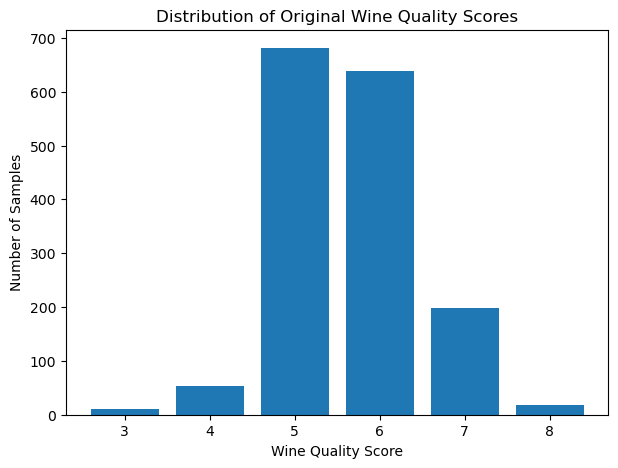

In [5]:
# Check original quality distribution

quality_counts = df['quality'].value_counts().sort_index()

print("Original quality score distribution:")
print(quality_counts)

plt.figure(figsize=(7, 5))
plt.bar(quality_counts.index, quality_counts.values)
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Samples")
plt.title("Distribution of Original Wine Quality Scores")
plt.show()

Binary class distribution:
0    744
1    855
Name: quality_binary, dtype: int64


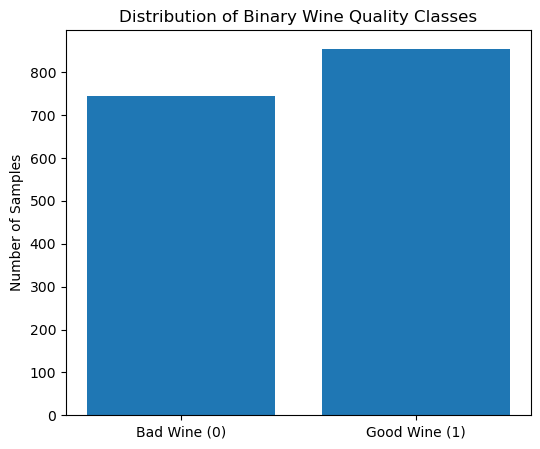

In [6]:
# 6. Convert quality into binary classification target
# quality >= 6: good wine = 1
# quality < 6: bad wine = 0

df['quality_binary'] = (df['quality'] >= 6).astype(int)

binary_counts = df['quality_binary'].value_counts().sort_index()

print("Binary class distribution:")
print(binary_counts)

plt.figure(figsize=(6, 5))
plt.bar(["Bad Wine (0)", "Good Wine (1)"], binary_counts.values)
plt.ylabel("Number of Samples")
plt.title("Distribution of Binary Wine Quality Classes")
plt.show()

In [7]:
# Define features X and target y

X = df.drop(columns=['quality', 'quality_binary'])
y = df['quality_binary']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

display(X.head())

Feature matrix shape: (1599, 11)
Target vector shape: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [8]:
# Train-test split
# stratify=y keeps the good/bad ratio similar in train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train distribution:
1    0.534793
0    0.465207
Name: quality_binary, dtype: float64

y_test distribution:
1    0.534375
0    0.465625
Name: quality_binary, dtype: float64


In [9]:
# Feature scaling (Preparation for SVM)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for easier reading
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
745,-0.590966,-0.088985,-0.479265,-0.318464,-0.362708,-0.376379,-0.555343,0.485602,1.350662,0.432631,-0.874168
823,-0.932515,0.078962,-0.737340,-0.390869,-0.232593,-0.082760,-0.314237,0.288102,1.935417,-0.111633,-0.594279
983,0.433678,-0.144968,0.140115,-0.463274,-0.471137,-0.767871,-0.886864,0.516786,0.051206,0.311684,0.058793
1505,-0.932515,1.310575,-1.305106,-0.535679,-0.189221,-0.963618,-1.037555,-0.387555,1.545580,-0.172107,-0.454335
1399,-0.647891,0.806733,-1.408336,-0.246059,-0.406080,-0.572125,-0.675896,-0.595449,0.700934,0.372157,0.618570


In [10]:
# Final preprocessing check

print("Preprocessing complete.")
print("Unscaled training data:", X_train.shape)
print("Scaled training data:", X_train_scaled.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Preprocessing complete.
Unscaled training data: (1279, 11)
Scaled training data: (1279, 11)
Training target: (1279,)
Testing target: (320,)


##### Method 1: Logicstic Regression (baseline)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:")
print(log_accuracy)

Logistic Regression Accuracy:
0.740625


In [12]:
# Confusion Matrix

cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix:")
print(cm_log)

Confusion Matrix:
[[111  38]
 [ 45 126]]


In [13]:
print("Classification Report:")

print(classification_report(
    y_test,
    y_pred_log
))

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       149
           1       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



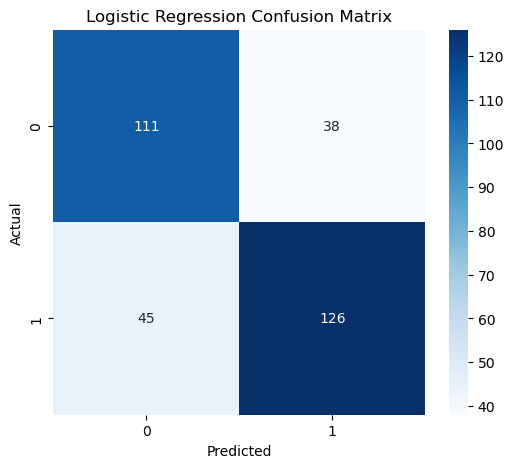

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Method 2: Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.81875
